In [1]:
pip install folium pandas geopandas shapely numpy psycopg2-binary geoalchemy2 sqlalchemy seaborn cartopy matplotlib rasterio xarray dataframe-image rioxarray fiona reportlab jinja2 pdfkit ipykernel


Note: you may need to restart the kernel to use updated packages.


In [2]:
import folium #cria mapas interativos baseados em Leaflet (mapas que você pode dar zoom, clicar, etc.)
from folium.plugins import MousePosition #plugin que mostra as coordenadas (latitude/longitude) do mouse no mapa.
import pandas as pd #1.Manipulação e análise de dados em tabelas (DataFrames); 2.Leitura de CSV, Excel, SQL, etc; 3. Filtragem, agregação e limpeza de dados.
import geopandas as gpd #1.Extensão do Pandas para dados geoespaciais; 2.Trabalha com shapefiles, GeoJSON, coordenadas, projeções; #3.Usa geometria (pontos, linhas, polígonos).
import shapely as sp #1.Criação e manipulação de geometrias (ponto, linha, polígono); 2.Cálculo de área, interseção, buffer, distância, etc; 3.Base geométrica do GeoPandas.
import numpy as np #Operações matemáticas e numéricas rápidas; 2.Trabalha com arrays multidimensionais; 3. Base para muitas outras bibliotecas científicas.
import psycopg2 #1.Conector Python ↔ PostgreSQL; 2.Usado para acessar bancos de dados PostgreSQL/PostGIS diretamente.
import geoalchemy2 #1.Extensão espacial do SQLAlchemy; #2.Permite trabalhar com PostGIS (dados geográficos no PostgreSQL); 3.Integra banco de dados + geometria.
from sqlalchemy import create_engine #1.Biblioteca ORM (Object Relational Mapper); 2.Cria conexões com bancos de dados; 3.create_engine cria a conexão com o banco (Postgres, MySQL, etc.).
import seaborn as sns #1.Visualização de dados estatísticos; 2.Gráficos bonitos e prontos (histogramas, boxplot, heatmap); 3.Baseado no Matplotlib.
import cartopy.feature as cfeature #1.Criação de mapas cartográficos; 2.cfeature: elementos do mapa (rios, fronteiras, costas); 3.ccrs: sistemas de coordenadas e projeções cartográficas.
import matplotlib.pyplot as plt #1.Biblioteca principal de gráficos em Python; 2.Gráficos de linha, barras, mapas, etc; 3.Base para Seaborn e Cartopy.
import cartopy.crs as ccrs #Define: 1.Projeções cartográficas; 2.Sistemas de coordenadas geográficas; 3.Conversões entre projeções.
import rasterio #1.Leitura e processamento de dados raster (imagens de satélite, DEM, NDVI).
from rasterio.mask import mask #mask: recorte de raster por geometria
from rasterio.plot import show #show: exibir raster
from rasterio.enums import Resampling #Resampling: métodos de reamostragem
from rasterio.transform import from_origin #É uma função que cria a transformação espacial de um raster (onde cada pixel está localizado no mundo real). Define:1.Onde o raster começa no espaço (coordenadas); 2.Qual o tamanho do pixel; 3.Como linhas e colunas se relacionam com coordenadas reais
from rasterio.io import MemoryFile #MemoryFile: trabalhar com raster em memória (sem salvar em disco)
from rasterio.warp import calculate_default_transform, reproject, Resampling #1.Trabalha com dados multidimensionais (tempo, latitude, longitude); 2.Muito usado em dados climáticos, meteorológicos e satélite; 3.Integra bem com NetCDF e raster.
import xarray as xr #Trabalha com dados multidimensionais (tempo, latitude, longitude); 2.Muito usado em dados climáticos, meteorológicos e satélite; 3.Integra bem com NetCDF e raster.
import rioxarray #É uma extensão do xarray baseada no Rasterio, usada para: 1.Ler e salvar rasters georreferenciados (GeoTIFF, NetCDF, etc.); 2.Associar CRS (sistema de coordenadas) aos dados; 3.Fazer recortes, reprojeções e máscaras espaciais; 4.Trabalhar com dados raster multidimensionais (tempo, bandas)
##import dataframe_image as dfi #1.Exporta DataFrames como imagens (PNG); 2.Útil para relatórios e apresentações.
from jinja2 import Environment, FileSystemLoader #Fornecer suporte nativo à linguagem de templates dentro do editor, facilitando a escrita de código dinâmico, especialmente para desenvolvimento web (Flask, Django) ou automações 
import pdfkit #converter HTML em documentos PDF
import ipykernel



c:\Users\fabio.passos\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Delimitação do Período  

In [5]:
# Delimitação do Período

#1. Definir os períodos que deseja comparar (Início, Fim, Rótulo)
import urllib.parse
from sqlalchemy import create_engine
import pandas as pd

# ==============================================================================
# 1. DELIMITAÇÃO DOS PERÍODOS
# ==============================================================================
periodos = {
    "Julho 2026": ("2026-07-06", "2026-07-10"),
    "Agosto 2026": ("2026-08-03", "2026-08-07"),
}


# Delimitação por Localidade

In [6]:
# ==============================================================================
# CONFIGURAÇÃO DOS FILTROS DE LOCALIDADE
# ==============================================================================
# Defina o tipo de filtro desejado e o valor:
# Opções para 'tipo_filtro': 
#   - 'todos'          (Não aplica filtro adicional)
#   - 'amazonia_legal' (Apenas o limite da Amazônia Legal)
#   - 'bioma'          (Ex: 'Amazônia', 'Cerrado', 'Pantanal')
#   - 'regiao'         (Ex: 'Norte', 'Nordeste', 'Centro-Oeste')
#   - 'estado'         (Ex: 'AM', 'PA', 'MT')
#   - 'municipio'      (Ex: 'Manaus', 'Porto Velho', 'Altamira')

tipo_filtro = 'amazonia_lega1'   # Opções: 'todos', 'amazonia_legal', 'bioma', 'regiao', 'estado', 'municipio'
valor_filtro = 'todos' # Pode ser uma string 'AM' ou tupla/lista ('AM', 'RR')

def formatar_valores_sql(valores):
    """Converte valores simples ou listas/tuplas na sintaxe SQL ('VALOR1', 'VALOR2')"""
    if isinstance(valores, (list, tuple, set)):
        itens_formatados = ", ".join([f"'{str(v).strip().lower()}'" for v in valores])
        return f"({itens_formatados})"
    else:
        return f"('{str(valores).strip().lower()}')"


In [7]:
# ==============================================================================
# 3. CONSTRUÇÃO DAS LOCALIDADES
# ==============================================================================
join_filtro = ""
where_filtro = ""
valores_sql = formatar_valores_sql(valor_filtro)

if tipo_filtro == 'amazonia_legal':
    join_filtro = "JOIN bases_auxiliares.censipam_amazonia_legal_u AS f ON ST_Intersects(mv.geom_acumulada, f.geom)"

elif tipo_filtro == 'bioma':
    join_filtro = "JOIN bases_auxiliares.biomas AS f ON ST_Intersects(mv.geom_acumulada, f.geom)"
    where_filtro = f"AND LOWER(f.bioma) IN {valores_sql}"

elif tipo_filtro == 'regiao':
    join_filtro = "JOIN bases_auxiliares.censipam_amazonia_legal_2019 AS f ON ST_Intersects(mv.geom_acumulada, f.geom)"
    where_filtro = f"AND LOWER(f.regiao) IN {valores_sql}"

elif tipo_filtro == 'estado':
    # Tabela corrigida: ibge_bc250_lim_unidade_federacao_a
    join_filtro = "JOIN bases_auxiliares.ibge_bc250_lim_unidade_federacao_a AS f ON ST_Intersects(mv.geom_acumulada, f.geom)"
    where_filtro = f"AND (LOWER(f.sigla) IN {valores_sql} OR LOWER(f.sigla) IN {valores_sql})"

elif tipo_filtro == 'municipio':
    join_filtro = "JOIN bases_auxiliares.ibge_bc250_lim_municipios_amazonia_legal_2019 AS f ON ST_Intersects(mv.geom_acumulada, f.geom)"
    where_filtro = f"AND LOWER(f.nm_mun) IN {valores_sql}"

Acesso ao Banco de Dados

In [8]:
# Acesso ao Banco de Dados
def ler_credencial(caminho_arquivo):
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        return f.read().strip()

caminho_user = r"D:\Fabio\5.projetos\2025\1.automatização_relatorios\acesso\user.txt"
caminho_pass = r"D:\Fabio\5.projetos\2025\1.automatização_relatorios\acesso\pass.txt"

usuario = ler_credencial(caminho_user)
senha_bruta = ler_credencial(caminho_pass)
senha = urllib.parse.quote_plus(senha_bruta)

host = "172.23.5.229"
porta = "5432"
banco = "sig_sipam"

conn_str = f"postgresql://{usuario}:{senha}@{host}:{porta}/{banco}"
engine = create_engine(conn_str)


# Texto formatado para títulos dos gráficos e tabelas
if tipo_filtro == 'todos':
    localidade_str = "Toda a área de estudo"
elif tipo_filtro == 'amazonia_legal':
    localidade_str = "Amazônia Legal"
else:
    valores = ", ".join(map(str, valor_filtro)) if isinstance(valor_filtro, (list, tuple, set)) else str(valor_filtro)
    localidade_str = f"{tipo_filtro.capitalize()}: {valores}"


# GRÁFICO DE BARRAS 

In [9]:
# GRÁFICO DE OCORRÊNCIA DE FOGO NOS ESTADOS DA AMAZÔNIA LEGAL

resultados_graficos = {}

for nome_periodo, (inicio, fim) in periodos.items():
    sql = f"""
    SELECT 
        y.sigla AS uf, 
        COUNT(DISTINCT sub.id_evento) AS total_eventos    
    FROM (
        SELECT DISTINCT ON (mv.id_evento) 
            mv.id_evento, 
            mv.geom_acumulada
        FROM 
            queimadas.mv_indicadores_queimadas mv
        JOIN 
            bases_auxiliares.censipam_amazonia_legal_u AS x ON ST_Intersects(mv.geom_acumulada, x.geom)
        {join_filtro}
        WHERE 
            mv.area_acumulada_ha >= 100
            AND mv.dt_passagem BETWEEN '{inicio}' AND '{fim}'
            {where_filtro}
        ORDER BY 
            mv.id_evento, mv.dt_passagem DESC
    ) AS sub  
    JOIN 
        bases_auxiliares.censipam_amazonia_legal_2019 AS y 
        ON ST_Intersects(sub.geom_acumulada, y.geom)
    WHERE 1=1
        {where_filtro.replace('f.', 'y.') if tipo_filtro == 'estado' else ''}
    GROUP BY 
        y.sigla 
    ORDER BY 
        total_eventos DESC;
    """
    resultados_graficos[nome_periodo] = pd.read_sql(sql, engine)
    print(f"Dados do gráfico ({nome_periodo}) carregados com sucesso.")

Dados do gráfico (Julho 2026) carregados com sucesso.
Dados do gráfico (Agosto 2026) carregados com sucesso.


## Gráfico de barras separado

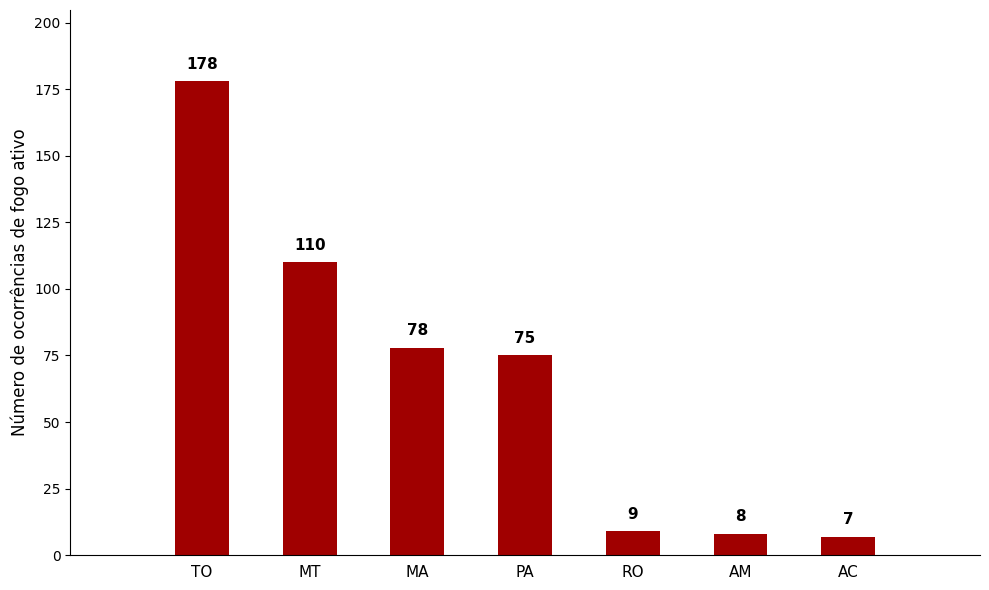

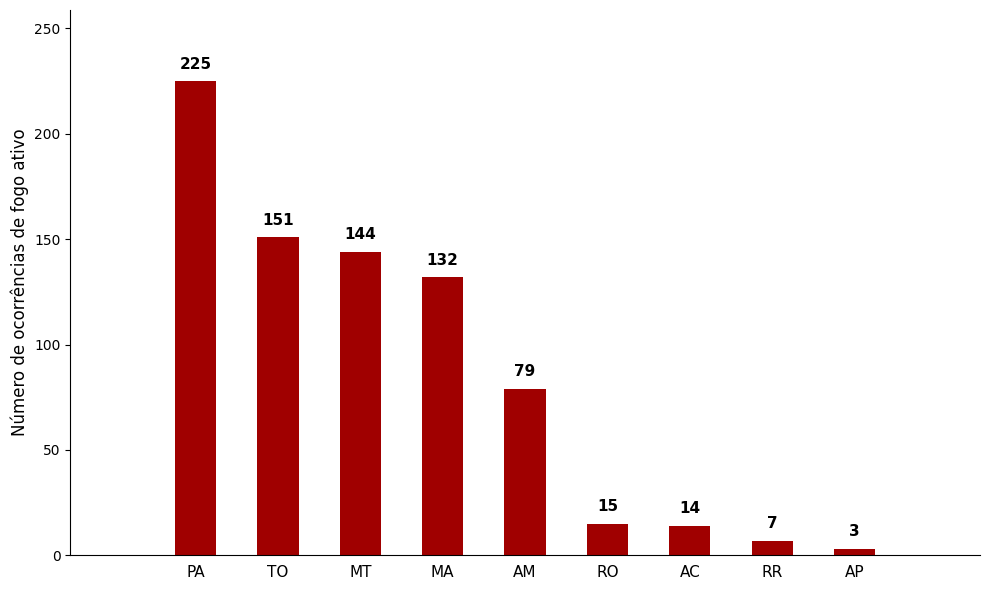

In [27]:
#| label: grafico-UF_separados

##########################################
## Geração de Gráficos de Barras Separados
##########################################

for nome, df in resultados_graficos.items():
    if df.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Desenha as barras centralizadas automaticamente (com largura controlada)
    bars = ax.bar(df['uf'], df['total_eventos'], color='#A00000', width=0.5) 

    # 2. Remoção limpa das bordas (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)   # Mantiene o eixo Y no canto esquerdo padrão
    ax.spines['bottom'].set_visible(True)

    # 3. Ajuste automático dos limites do Eixo Y (dá 15% de folga no topo para o texto não cortar)
    max_val = df['total_eventos'].max()
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 10)

    # 4. Adiciona os rótulos numéricos sobre cada barra
    for bar in bars:
        altura = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            altura + (max_val * 0.02), # folga proporcional
            f'{int(altura)}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    # 5. Estilização dos ticks e eixos
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelsize=11)
    ax.tick_params(axis='y', which='both', left=True, right=False, labelsize=10)
    ax.set_ylabel('Número de ocorrências de fogo ativo', fontsize=12)

    # Margem lateral automática nas extremidades da figura
    ax.margins(x=0.15)

    plt.tight_layout()
    plt.show()


## Gráfico de barras multiplas

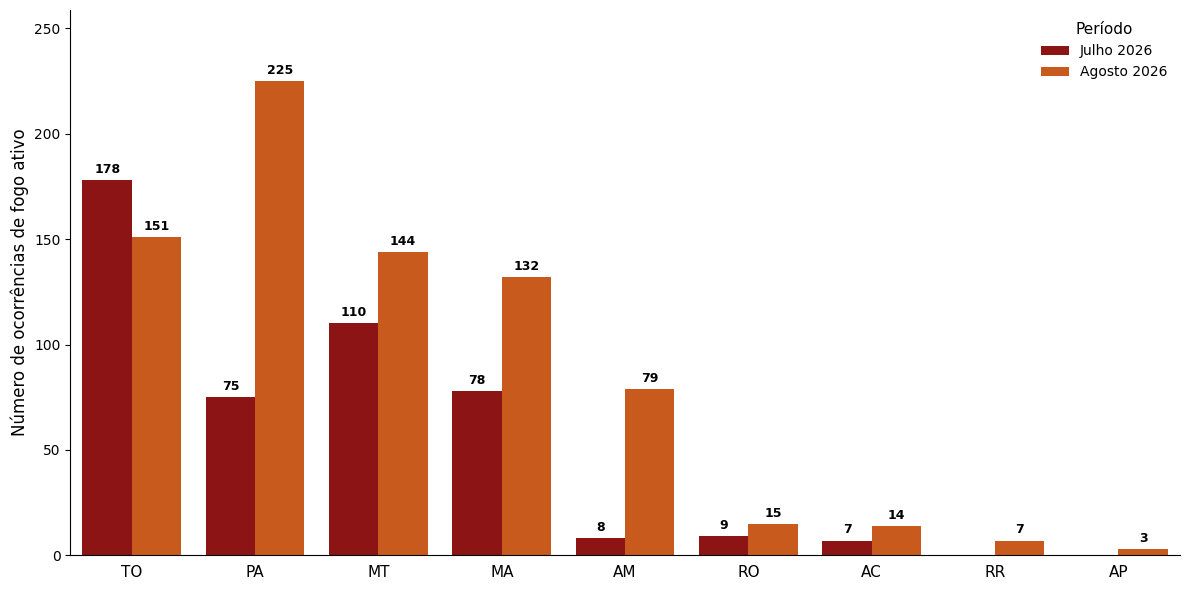

In [25]:
#| label: grafico-UF_unificado

##########################################
## Geração de Gráficos de Barras Unificado
##########################################

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Consolidação dos dados de todos os períodos
lista_dfs = []
for nome_periodo, df in resultados_graficos.items():
    if not df.empty:
        df_temp = df.copy()
        df_temp["PERÍODO"] = nome_periodo.replace("_", " ")
        lista_dfs.append(df_temp)

if lista_dfs:
    df_grafico = pd.concat(lista_dfs, ignore_index=True)

    # Ordena as UFs com base no total acumulado para manter o gráfico organizado
    ordem_ufs = (
        df_grafico.groupby("uf")["total_eventos"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    # 2. Configuração da Figura
    fig, ax = plt.subplots(figsize=(12, 6))

    # Paleta de cores para os períodos (ajuste as cores se desejar)
    cores = ["#A00000", "#E65100", "#F57C00", "#FFB74D", "#D32F2F"]

    # 3. Desenho das barras agrupadas automaticamente via Seaborn
    sns.barplot(
        data=df_grafico,
        x="uf",
        y="total_eventos",
        hue="PERÍODO",
        order=ordem_ufs,
        palette=cores[: len(df_grafico["PERÍODO"].unique())],
        ax=ax,
    )

    # 4. Remoção limpa das bordas (spines)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    # 5. Limites do Eixo Y com folga para os rótulos
    max_val = df_grafico["total_eventos"].max()
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 10)

    # 6. Rótulos numéricos centralizados sobre CADA barra agrupada
    for p in ax.patches:
        altura = p.get_height()
        if not pd.isna(altura) and altura > 0:
            ax.annotate(
                f"{int(altura)}",
                (p.get_x() + p.get_width() / 2.0, altura),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                xytext=(0, 3),
                textcoords="offset points",
            )

    # 7. Estilização dos eixos, legenda e rótulos
    ax.tick_params(
        axis="x", which="both", bottom=False, top=False, labelsize=11
    )
    ax.tick_params(
        axis="y", which="both", left=True, right=False, labelsize=10
    )
    ax.set_xlabel("")
    ax.set_ylabel("Número de ocorrências de fogo ativo", fontsize=12)

    # Legenda ajustada no topo fora da área das barras
    ax.legend(
        title="Período",
        frameon=False,
        fontsize=10,
        title_fontsize=11,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()

# TABELA DOS MUNICIPIOS 3+
Separar as duas consultas


In [74]:

# RANKING DE EVENTOS DE FOGO POR MUNICIPIO DA AMAZÔNIA LEGAL

# ==============================================================================
# 8. CONSULTAS SQL: TABELAS MUNICIPAIS (COM FILTRO APLICADO)
# ==============================================================================
resultados_tabela = {}
resultados_munic_queimados = {}

for nome_periodo, (inicio, fim) in periodos.items():
    # Consulta 1: Ranking por N° de Eventos
    sql_2 = f"""
    SELECT 
        x.nm_mun AS municipio,
        x.sigla AS uf,
        COUNT(DISTINCT sub.id_evento) AS total_eventos,
        SUM(st_area(st_transform(st_intersection(sub.geom_acumulada, x.geom), 5880))) / 1000000 as area_eve_km2,
        ST_AREA(ST_Transform(x.geom, 5880)) / 1000000 AS area_mun_km2
    FROM (
        SELECT DISTINCT ON (mv.id_evento)
            mv.id_evento,
            mv.dt_passagem,
            mv.geom_acumulada
        FROM 
            queimadas.mv_indicadores_queimadas mv
        JOIN 
            bases_auxiliares.censipam_amazonia_legal_u AS c ON ST_Intersects(mv.geom_acumulada, c.geom)
        {join_filtro}
        WHERE    
            mv.area_acumulada_ha >= 100
            AND mv.dt_passagem BETWEEN '{inicio}' AND '{fim}'
            {where_filtro}
        ORDER BY 
            mv.id_evento, mv.dt_passagem DESC
    ) AS sub  
    JOIN 
        bases_auxiliares.ibge_bc250_lim_municipios_amazonia_legal_2019 AS x ON ST_Intersects(sub.geom_acumulada, x.geom)
    GROUP BY 
        x.nm_mun, x.sigla, x.geom
    ORDER BY 
        total_eventos DESC
    LIMIT 3;

    """

    # Consulta 2: Ranking por Percentual da Área Queimada
    sql_3 = f"""
    SELECT 
        x.nm_mun AS municipio,
        x.sigla AS uf,
        COUNT(DISTINCT sub.id_evento) AS total_eventos,
        SUM(st_area(st_transform(st_intersection(sub.geom_acumulada, x.geom), 5880))) / 1000000 as area_eve_km2,
        ST_AREA(ST_Transform(x.geom, 5880)) / 1000000 AS area_mun_km2,
        (
            SUM(st_area(st_transform(st_intersection(sub.geom_acumulada, x.geom), 5880))) / 1000000 /
            (ST_AREA(ST_Transform(x.geom, 5880)) / 1000000) * 100
        ) as percentual_queimado
    FROM (
        SELECT DISTINCT ON (mv.id_evento)
            mv.id_evento,
            mv.dt_passagem,
            mv.geom_acumulada
        FROM 
            queimadas.mv_indicadores_queimadas mv
        JOIN 
            bases_auxiliares.censipam_amazonia_legal_u AS c ON ST_Intersects(mv.geom_acumulada, c.geom)
        {join_filtro}
        WHERE    
            mv.area_acumulada_ha >= 100
            AND mv.dt_passagem BETWEEN '{inicio}' AND '{fim}'
            {where_filtro}
        ORDER BY 
            mv.id_evento, mv.dt_passagem DESC
    ) AS sub  
    JOIN 
        bases_auxiliares.ibge_bc250_lim_municipios_amazonia_legal_2019 AS x ON ST_Intersects(sub.geom_acumulada, x.geom)
    GROUP BY 
        x.nm_mun, x.sigla, x.geom
    ORDER BY 
        percentual_queimado DESC
    LIMIT 3;
    """

    resultados_tabela[nome_periodo] = pd.read_sql(sql_2, engine)
    resultados_munic_queimados[nome_periodo] = pd.read_sql(sql_3, engine)
    print(f"Tabelas de municípios do período {nome_periodo} carregadas.")


Tabelas de municípios do período Julho 2026 carregadas.
Tabelas de municípios do período Agosto 2026 carregadas.


In [72]:
resultados_tabela = {}
resultados_munic_queimados = {}

for nome_periodo, (inicio, fim) in periodos.items():

    # Consulta 2: Ranking por Percentual da Área Queimada
    sql_3 = f"""
    SELECT 
        x.nm_mun AS municipio,
        x.sigla AS uf,
        COUNT(DISTINCT sub.id_evento) AS total_eventos,
        SUM(st_area(st_transform(st_intersection(sub.geom_acumulada, x.geom), 5880))) / 1000000 as area_eve_km2,
        ST_AREA(ST_Transform(x.geom, 5880)) / 1000000 AS area_mun_km2,
        (
            SUM(st_area(st_transform(st_intersection(sub.geom_acumulada, x.geom), 5880))) / 1000000 /
            (ST_AREA(ST_Transform(x.geom, 5880)) / 1000000) * 100
        ) as percentual_queimado
    FROM (
        SELECT DISTINCT ON (mv.id_evento)
            mv.id_evento,
            mv.dt_passagem,
            mv.geom_acumulada
        FROM 
            queimadas.mv_indicadores_queimadas mv
        JOIN 
            bases_auxiliares.censipam_amazonia_legal_u AS c ON ST_Intersects(mv.geom_acumulada, c.geom)
        {join_filtro}
        WHERE    
            mv.area_acumulada_ha >= 100
            AND mv.dt_passagem BETWEEN '{inicio}' AND '{fim}'
            {where_filtro}
        ORDER BY 
            mv.id_evento, mv.dt_passagem DESC
    ) AS sub  
    JOIN 
        bases_auxiliares.ibge_bc250_lim_municipios_amazonia_legal_2019 AS x ON ST_Intersects(sub.geom_acumulada, x.geom)
    GROUP BY 
        x.nm_mun, x.sigla, x.geom
    ORDER BY 
        percentual_queimado DESC
    LIMIT 3;
    """

    resultados_tabela[nome_periodo] = pd.read_sql(sql_2, engine)
    resultados_munic_queimados[nome_periodo] = pd.read_sql(sql_3, engine)
    print(f"Tabelas de municípios do período {nome_periodo} carregadas.")

Tabelas de municípios do período Julho 2026 carregadas.
Tabelas de municípios do período Agosto 2026 carregadas.


### Opção 1: Geração de múltiplas Tabelas dos meses selecioandos separadamente
            ### Sem opção "Salvar como"


In [75]:
#| label: tabela-municipios

# Iterar sobre os resultados armazenados para gerar uma tabela por período
for nome_periodo, df_original in resultados_tabela.items():
    
    # Criar uma cópia para não alterar os dados originais
    tabela = df_original.copy()

    # 1. Tratamento de Dados
    tabela = tabela.sort_values(by='total_eventos', ascending=False)
    tabela = tabela.rename(columns={'uf': 'UF', 'municipio': 'MUNICÍPIO', 'total_eventos': 'N° DE EVENTOS'})
    
    # Criando a coluna posição
    tabela['POSIÇÃO'] = ['{}°'.format(i+1) for i in range(len(tabela))]
    
    # Cálculos e Formatação Brasileira (Vírgula como separador decimal)
    tabela['ÁREA DE EVENTOS NO MUNICÍPIO (%)'] = (tabela['area_eve_km2'] / tabela['area_mun_km2'] * 100).map('{:.2f}'.format).str.replace('.', ',')
    tabela['ÁREA DE EVENTOS (KM²)'] = tabela['area_eve_km2'].map('{:,.2f}'.format).str.replace(',', 'X').str.replace('.', ',').str.replace('X', '.')

    # 2. Reorganização de Colunas
    nova_ordem = ['POSIÇÃO', 'MUNICÍPIO', 'UF', 'N° DE EVENTOS','ÁREA DE EVENTOS (KM²)','ÁREA DE EVENTOS NO MUNICÍPIO (%)']
    tabela = tabela[nova_ordem]

    # 3. Exibição com Estilo
    print(f"\n--- RANKING: {nome_periodo} ---")
    
    # Aplicando o estilo (em Notebooks/VSCode use display() para renderizar o HTML)
    estilo = tabela.style.set_table_styles([
        {'selector': 'th.col_heading', 'props': [('text-align', 'center !important')]},
        {'selector': 'thead', 'props': [('background-color', '#A00000'), 
                                        ('color', 'white'), 
                                        ('font-weight', 'bold'),
                                        ('font-size', '14px'),
                                        ('text-align', 'center'),  # Centraliza o texto do título
                                        ('vertical-align', 'middle') # Centraliza verticalmente
                                        ]},
        {'selector': 'td', 'props': [('text-align', 'center'), 
                                     ('color', 'black'), 
                                     ('font-size', '18px'),
                                     #('border', '1px solid #ddd') # bordas finas para separar células
                                     ]},
    ]).apply(lambda x: ['background-color: #FED9D5' if i % 2 else 'background-color: white' 
                        for i in range(len(x))], axis=0).hide(axis="index")
    
    display(estilo) # O comando display garante a visualização rica no VSCode






--- RANKING: Julho 2026 ---


POSIÇÃO,MUNICÍPIO,UF,N° DE EVENTOS,ÁREA DE EVENTOS (KM²),ÁREA DE EVENTOS NO MUNICÍPIO (%)
1°,Mateiros,TO,20,"78,50","0,81"
2°,Campinápolis,MT,19,"42,31","0,71"
3°,Lagoa da Confusão,TO,17,"66,91","0,63"



--- RANKING: Agosto 2026 ---


POSIÇÃO,MUNICÍPIO,UF,N° DE EVENTOS,ÁREA DE EVENTOS (KM²),ÁREA DE EVENTOS NO MUNICÍPIO (%)
1°,Lagoa da Confusão,TO,36,"246,89","2,33"
2°,Fernando Falcão,MA,29,"107,56","2,09"
3°,São Félix do Xingu,PA,22,"47,60","0,06"


##### Opção 2: Geração de múltiplas Tabelas dos meses selecioandos separadamente
            Com opção "Salvar como"
            Boletim da Amazônia


In [ ]:


import os
import dataframe_image as dfi

# Pasta onde os arquivos serão salvos
pasta_saida = r"D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\8.Ago26\imagens"
os.makedirs(pasta_saida, exist_ok=True)

# Iterar sobre os resultados armazenados para gerar uma tabela por período
for nome_periodo, df_original in resultados_tabela.items():
    
    # Criar uma cópia para não alterar os dados originais
    tabela = df_original.copy()

    # 1. Tratamento de Dados
    tabela = tabela.sort_values(by='total_eventos', ascending=False)
    tabela = tabela.rename(columns={'uf': 'UF', 'municipio': 'MUNICÍPIO', 'total_eventos': 'N° DE EVENTOS'})
    
    # Criando a coluna posição
    tabela['POSIÇÃO'] = ['{}°'.format(i+1) for i in range(len(tabela))]
    
    # Cálculos e Formatação Brasileira (Vírgula como separador decimal)
    tabela['ÁREA DE EVENTOS NO MUNICÍPIO (%)'] = (tabela['area_eve_km2'] / tabela['area_mun_km2'] * 100).map('{:.2f}'.format).str.replace('.', ',')
    tabela['ÁREA DE EVENTOS (KM²)'] = tabela['area_eve_km2'].map('{:,.2f}'.format).str.replace(',', 'X').str.replace('.', ',').str.replace('X', '.')

    # 2. Reorganização de Colunas
    nova_ordem = ['POSIÇÃO', 'MUNICÍPIO', 'UF', 'N° DE EVENTOS','ÁREA DE EVENTOS (KM²)','ÁREA DE EVENTOS NO MUNICÍPIO (%)']
    tabela = tabela[nova_ordem]

    # 3. Exibição e Estilização HTML Única
    print(f"\n--- RANKING: {nome_periodo} ---")
    
    estilo = tabela.style.set_table_styles([
        {'selector': 'th.col_heading', 'props': [('text-align', 'center !important')]},
        {'selector': 'thead', 'props': [('background-color', '#A00000'), 
                                        ('color', 'white'), 
                                        ('font-weight', 'bold'),
                                        ('font-size', '14px'),
                                        ('text-align', 'center'),  # Centraliza o texto do título
                                        ('vertical-align', 'middle') # Centraliza verticalmente
                                        ]},
        {'selector': 'td', 'props': [('text-align', 'center'), 
                                     ('color', 'black'), 
                                     ('font-size', '18px'),
                                     #('border', '1px solid #ddd') # bordas finas para separar células
                                     ]},
    ]).apply(lambda x: ['background-color: #FED9D5' if i % 2 else 'background-color: white' 
                        for i in range(len(x))], axis=0).hide(axis="index")

    display(estilo) # O comando display garante a visualização rica no VSCode

    # 4. Exportação dos Dados para Excel (.xlsx)
    caminho_xlsx = os.path.join(pasta_saida, f"tabela_municipios_{nome_periodo}.xlsx")
    tabela.to_excel(caminho_xlsx, index=False)

    # 5. Exportação da Tabela Estilizada diretamente para Imagem (.png)
    caminho_png = os.path.join(pasta_saida, f"tabela_municipios_{nome_periodo}.png")
    dfi.export(estilo, caminho_png, table_conversion="matplotlib")

    print(f"✔ Planilha salva em: {caminho_xlsx}")
    print(f"✔ Imagem salva em: {caminho_png}\n")


--- RANKING: Julho 2026 ---

--- RANKING: Agosto 2026 ---


### Geração de múltiplas Tabelas dos períodos e localidades selecioandos unificadas por UF


In [78]:
#| label: Tabela_unificado_UF

##########################################
## Geração de Tabelas Unificadas por UF
##########################################



lista_tabelas = []

# 1. Iterar sobre os resultados para tratar e acumular os dados
for nome_periodo, df_original in resultados_tabela.items():
    if df_original.empty:
        continue
        
    tabela = df_original.copy()

    # Tratamento de Dados
    tabela = tabela.sort_values(by='total_eventos', ascending=False)
    tabela = tabela.rename(columns={'uf': 'UF', 'municipio': 'MUNICÍPIO', 'total_eventos': 'N° DE EVENTOS'})
    
    # Adicionando identificador do período
    tabela['PERÍODO'] = nome_periodo.replace('_', ' ')
    
    # Criando a coluna posição dentro de cada período
    tabela['POSIÇÃO'] = ['{}°'.format(i+1) for i in range(len(tabela))]
    
    # Cálculos e Formatação Brasileira
    tabela['ÁREA DE EVENTOS NO MUNICÍPIO (%)'] = (tabela['area_eve_km2'] / tabela['area_mun_km2'] * 100).map('{:.2f}'.format).str.replace('.', ',')
    tabela['ÁREA DE EVENTOS (KM²)'] = tabela['area_eve_km2'].map('{:,.2f}'.format).str.replace(',', 'X').str.replace('.', ',').str.replace('X', '.')

    lista_tabelas.append(tabela)

# 2. Unificação de todas as tabelas em uma única
if lista_tabelas:
    tabela_unificada = pd.concat(lista_tabelas, ignore_index=True)

    # 3. Reorganização de Colunas
    nova_ordem = ['PERÍODO', 'POSIÇÃO', 'MUNICÍPIO', 'UF', 'N° DE EVENTOS', 'ÁREA DE EVENTOS (KM²)', 'ÁREA DE EVENTOS NO MUNICÍPIO (%)']
    tabela_unificada = tabela_unificada[nova_ordem]

    # 4. Exibição com Estilo
    print("\n--- RANKING UNIFICADO ---")

    # Função para aplicar efeito zebra e borda ao mudar de PERÍODO
    def aplicar_estilos_por_periodo(df):
        styles = pd.DataFrame('', index=df.index, columns=df.columns)
        
        # Cria uma lista de booleanos indicando onde o PERÍODO muda para a linha seguinte
        muda_periodo = df['PERÍODO'] != df['PERÍODO'].shift(-1)
        
        for idx in df.index:
            # Alterna tom de zebra por linha
            cor_zebra = '#FED9D5' if idx % 2 == 0 else '#FFF5F4'
            
            # Borda inferior reforçada na última linha de cada período
            if muda_periodo[idx]:
                estilo_linha = f'background-color: {cor_zebra}; border-bottom: 3px solid #A00000;'
            else:
                estilo_linha = f'background-color: {cor_zebra};'
                
            styles.loc[idx] = estilo_linha
            
        return styles

    # Aplicando os estilos CSS e a função customizada
    estilo = (tabela_unificada.style
              .set_table_styles([
                  {'selector': 'th.col_heading', 'props': [('text-align', 'center !important')]},
                  {'selector': 'thead', 'props': [
                      ('background-color', '#A00000'), 
                      ('color', 'white'), 
                      ('font-weight', 'bold'),
                      ('font-size', '14px'),
                      ('text-align', 'center'),
                      ('vertical-align', 'middle')
                  ]},
                  {'selector': 'td', 'props': [
                      ('text-align', 'center'), 
                      ('color', 'black'), 
                      ('font-size', '18px')
                  ]}
              ])
              .apply(aplicar_estilos_por_periodo, axis=None) # aplica na tabela inteira
              .hide(axis="index")
             )
    
    display(estilo)


--- RANKING UNIFICADO ---


PERÍODO,POSIÇÃO,MUNICÍPIO,UF,N° DE EVENTOS,ÁREA DE EVENTOS (KM²),ÁREA DE EVENTOS NO MUNICÍPIO (%)
Julho 2026,1°,Mateiros,TO,20,"78,50","0,81"
Julho 2026,2°,Campinápolis,MT,19,"42,31","0,71"
Julho 2026,3°,Lagoa da Confusão,TO,17,"66,91","0,63"
Agosto 2026,1°,Lagoa da Confusão,TO,36,"246,89","2,33"
Agosto 2026,2°,Fernando Falcão,MA,29,"107,56","2,09"
Agosto 2026,3°,São Félix do Xingu,PA,22,"47,60","0,06"


Geração de múltiplas Tabelas dos períodos selecionados e localidades separadamente


In [ ]:
for nome_periodo, df_original in resultados_tabela.items():
    if df_original.empty:
        continue
    
    # Identifica as UFs presentes no resultado (ex: 'AM', 'RR')
    ufs_presentes = sorted(df_original['uf'].unique())

    for uf_atual in ufs_presentes:
        # Filtra o DataFrame apenas para a UF atual e pega o TOP 10 daquele estado
        tabela = df_original[df_original['uf'] == uf_atual].copy()
        tabela = tabela.sort_values(by='total_eventos', ascending=False).head(10)
        
        
        if tabela.empty:
            continue

        # Tratamento e Formatação
        tabela = tabela.rename(columns={'uf': 'UF', 'municipio': 'MUNICÍPIO', 'total_eventos': 'N° DE EVENTOS'})
        tabela['POSIÇÃO'] = [f'{i+1}°' for i in range(len(tabela))]
        
        tabela['ÁREA DE EVENTOS NO MUNICÍPIO (%)'] = (tabela['area_eve_km2'] / tabela['area_mun_km2'] * 100).map('{:.2f}'.format).str.replace('.', ',')
        tabela['ÁREA DE EVENTOS (KM²)'] = tabela['area_eve_km2'].map('{:,.2f}'.format).str.replace(',', 'X').str.replace('.', ',').str.replace('X', '.')

        nova_ordem = ['POSIÇÃO', 'MUNICÍPIO', 'UF', 'N° DE EVENTOS', 'ÁREA DE EVENTOS (KM²)', 'ÁREA DE EVENTOS NO MUNICÍPIO (%)']
        tabela = tabela[nova_ordem]

        # Título Explicativo por Ano e Estado
        print(f"\n--- RANKING MUNICIPAL: PERÍODO {nome_periodo} | ESTADO: {uf_atual} ---")

        # Estilização HTML / Jupyter
        estilo = tabela.style.set_table_styles([
            {'selector': 'thead', 'props': [('background-color', '#A00000'), 
                                            ('color', 'white'), 
                                            ('font-weight', 'bold'),
                                            ('font-size', '14px'),
                                            ('text-align', 'center'),
                                            ('vertical-align', 'middle')]},
            {'selector': 'td', 'props': [('text-align', 'center'), 
                                         ('color', 'black'), 
                                         ('font-size', '15px')]},
        ]).apply(lambda x: ['background-color: #FED9D5' if i % 2 == 0 else 'background-color: white' 
                            for i in range(len(x))], axis=0).hide(axis="index")
        
        display(estilo)


--- RANKING MUNICIPAL: PERÍODO Julho 2026 | ESTADO: MA ---

--- RANKING MUNICIPAL: PERÍODO Julho 2026 | ESTADO: PA ---

--- RANKING MUNICIPAL: PERÍODO Julho 2026 | ESTADO: TO ---

--- RANKING MUNICIPAL: PERÍODO Agosto 2026 | ESTADO: MA ---

--- RANKING MUNICIPAL: PERÍODO Agosto 2026 | ESTADO: PA ---

--- RANKING MUNICIPAL: PERÍODO Agosto 2026 | ESTADO: TO ---


# Municipios 20+ com maiores percentual de território queimados

In [40]:

# RANKING DOS MUNICIPIOS DA AMAZÔNIA LEGAL COM MAIORES PERCENTUAL (EVENTOS DE FOGO) DE QUEIMADAS PELO TAMANHO DO SEU PERCENTUAL 

engine = create_engine(conn_str)

# 3. Dicionário para armazenar os DataFrames de cada período
resultados_munic_queimados = {}

for nome_periodo, (inicio, fim) in periodos.items():
        # A variável 'sql' é definida DENTRO do loop com as datas dinâmicas
    sql_4 =f"""
SELECT 
    x.nm_mun AS municipio,
    x.sigla AS uf,
    
    COUNT(DISTINCT sub.id_evento) AS total_eventos,
    
    -- Calcula a área queimada em Km2
    SUM(st_area(st_transform(st_intersection(sub.geom_acumulada,x.geom),5880)))/1000000 as area_eve_km2,
    
    -- Calcula a área do municipio em km2
    ST_AREA(ST_Transform(x.geom, 5880)) / 1000000 AS area_mun_km2,
    
    -- Calcula o percentual de área queimada nos municipios
    (
    SUM(st_area(st_transform(st_intersection(sub.geom_acumulada,x.geom),5880)))/1000000 
    /
    (ST_AREA(ST_Transform(x.geom, 5880)) / 1000000)
    *100
    ) as percentual_queimado
	
FROM 
	    (
		SELECT DISTINCT ON (mv.id_evento)
	        mv.id,
	        mv.id_evento,
	        mv.dt_passagem,
	        geom_acumulada
	    FROM 
	        queimadas.mv_indicadores_queimadas mv
	    JOIN 
	        bases_auxiliares.censipam_amazonia_legal_u AS x
	        ON ST_Intersects(mv.geom_acumulada, x.geom)
	    WHERE    
		mv.area_acumulada_ha >= 100
	        AND mv.dt_passagem BETWEEN '{inicio}' AND '{fim}'	    
ORDER BY 
	        mv.id_evento, mv.dt_passagem DESC
			) AS sub  

JOIN 
    bases_auxiliares.ibge_bc250_lim_municipios_amazonia_legal_2019 AS x
    ON ST_Intersects(sub.geom_acumulada, x.geom)

GROUP BY 
	x.nm_mun, x.sigla, x.geom
ORDER BY 
	percentual_queimado DESC
LIMIT 5
"""

# Executa a query e armazena no dicionário usando o [Pandas read_sql](https://pandas.pydata.org)
    resultados_munic_queimados[nome_periodo] = pd.read_sql(sql_3, engine)
    print(f"Tabela de {nome_periodo} carregada com sucesso.")


Tabela de Julho 2026 carregada com sucesso.
Tabela de Agosto 2026 carregada com sucesso.


In [41]:
#| label: munic_queimados-lista

##############################################################################################################
# Criação de Listagem com as informação dos períodos selecionados e Área Percentual do Municipio Queimada (%)
##############################################################################################################

# 1. Lista para coletar todos os dataframes
lista_final = []

# 2. Iterar sobre os resultados para coletar os dados
for nome_periodo, df_original in resultados_munic_queimados.items():
    # Usamos uma variável temporária para preparar cada bloco
    temp_df = df_original.copy()
    
    # Armazena o nome completo para garantir a ordenação correta depois
    
    temp_df['ORDEM_MES'] = nome_periodo 
    
    # Cria a coluna 'PERÍODO' 
    # '.split('_')[0] -> limpa o nome (ex: 'Dezembro_2025' -> 'Dezembro')
    # '.replace('_', ' ')-> unifica omês ao ano
    temp_df['PERÍODO'] = nome_periodo.replace('_', ' ')

    lista_final.append(temp_df)

# 3. Concatenar tudo na variável final munic_queimados (Fora do loop)
munic_queimados = pd.concat(lista_final, ignore_index=True) 

# 4. Ordenando por 'ORDEM_MES' (cronológico) e depois por 'percentual_queimado'
munic_queimados = munic_queimados.sort_values(by=['ORDEM_MES', 'percentual_queimado'], ascending=[True, False])

# 5. Criando a coluna 'POSIÇÃO' reiniciada a cada mês
munic_queimados['POSIÇÃO'] = (munic_queimados.groupby('PERÍODO').cumcount() + 1).map('{}°'.format)
      
# 6. Formatação dos valores percentuais (Padrão brasileiro)
munic_queimados['TOTAL QUEIMADO (%)'] = (
    (munic_queimados['area_eve_km2'] / munic_queimados['area_mun_km2']) * 100
).map('{:.2f}'.format).str.replace('.', ',')

# 7. Renomeação das colunas
munic_queimados = munic_queimados.rename(columns={'uf': 'UF', 'municipio': 'MUNICÍPIO'})

# 8. Definição da ordem das colunas
nova_ordem = ['PERÍODO', 'POSIÇÃO', 'MUNICÍPIO', 'UF', 'TOTAL QUEIMADO (%)']

# 9. Filtragem e reorganização
munic_queimados = munic_queimados[nova_ordem]

# 10. Exibição sem a coluna numérica de índice
print(munic_queimados.to_string(index=False))


    PERÍODO POSIÇÃO           MUNICÍPIO UF TOTAL QUEIMADO (%)
Agosto 2026      1°   Nova Santa Helena MT               4,64
Agosto 2026      2°   Lagoa da Confusão TO               2,33
Agosto 2026      3°     Fernando Falcão MA               2,09
Agosto 2026      4° Formoso do Araguaia TO               1,54
Agosto 2026      5°         Nova Nazaré MT               1,35
 Julho 2026      1°   Nova Santa Helena MT               4,64
 Julho 2026      2°   Lagoa da Confusão TO               2,33
 Julho 2026      3°     Fernando Falcão MA               2,09
 Julho 2026      4° Formoso do Araguaia TO               1,54
 Julho 2026      5°         Nova Nazaré MT               1,35


In [42]:
#| label: munic_queimados-tabela

##############################################################################################################
# Criação de Tabela com as informação dos períodos selecionados e Área Percentual do Municipio Queimada (%)
##############################################################################################################

def estilo_tabela_consolidada_munic(df):
    def aplicar_estilos(row):
        idx = row.name
        # 1. Efeito Zebra base
        cor_zebra = '#FED9D5' if idx % 2 == 0 else '#FFF5F4'
        estilo = [f'background-color: {cor_zebra}'] * len(row)
        
        # 2. Verificar se é a última linha de um mês para colocar a borda separadora
        # Se o índice atual for 19, 39, 59... (considerando 20 itens por mês)
        if (idx + 1) % 5 == 0:
            estilo = [f'background-color: {cor_zebra}; border-bottom: 3px solid #A00000'] * len(row)
            
        return estilo

    return df.style.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#A00000'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('font-size', '14px'),
            ('text-align', 'center'),
            ('vertical-align', 'middle')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'), 
            ('color', 'black'), 
            ('font-size', '16px'),
            ('padding', '8px')
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'), 
            ('width', '100%')
        ]}
    ]).apply(aplicar_estilos, axis=1).hide(axis="index")

# Exibição
display(estilo_tabela_consolidada_munic(munic_queimados))


PERÍODO,POSIÇÃO,MUNICÍPIO,UF,TOTAL QUEIMADO (%)
Agosto 2026,1°,Nova Santa Helena,MT,"4,64"
Agosto 2026,2°,Lagoa da Confusão,TO,"2,33"
Agosto 2026,3°,Fernando Falcão,MA,"2,09"
Agosto 2026,4°,Formoso do Araguaia,TO,"1,54"
Agosto 2026,5°,Nova Nazaré,MT,"1,35"
Julho 2026,1°,Nova Santa Helena,MT,"4,64"
Julho 2026,2°,Lagoa da Confusão,TO,"2,33"
Julho 2026,3°,Fernando Falcão,MA,"2,09"
Julho 2026,4°,Formoso do Araguaia,TO,"1,54"
Julho 2026,5°,Nova Nazaré,MT,"1,35"


                                        **MAPA DE EVENTOS DE FOGO E DIAS SEM CHUVAS**

# Sugestões
# 1. Criação dos Mapas de Fogo e Dias sem Chuva de acordo com os períodos (1, 2 ou mais mapas)
#       Ver fonte de acesso e download do aquivo *.nc com a Nilzele / Deydila

# 2. Criação apenas dos Mapas de Fogo com o HeatMap (sem Dias sem Chuva) de acordo com os períodos (1, 2 ou mais mapas)

In [48]:


# 1. Associação dos arquivos '.nc' com o período delimitado
# (podem estar em pastas diferentes)
# ================================
inputs_nc = {
    "Julho 2026": r"D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\7.Jul26\prec_dias-sem-chuva\DSC_MERGE_202606_01-30.nc",
    "Agosto 2026": r"D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\8.Ago26\prec_dias-sem-chuva\DSC_MERGE_202607_01-30.nc",
    
    
}


# Pasta de saída dos GeoTIFFs
output_dir = { 
    "Julho 2026": r"D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\7.Jul26\prec_dias-sem-chuva",
    "Agosto 2026": r"D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\8.Ago26\prec_dias-sem-chuva" 
              }

In [49]:
# 2. Carregamento do shp da Amazônia Legal
sql_amz = """
SELECT cd_uf, geom
FROM bases_auxiliares.censipam_amazonia_legal_2019;
"""
amazonia_b = gpd.read_postgis(
    sql_amz, con=conn_str, geom_col="geom"
).set_crs("EPSG:4674")

In [50]:
###########################################################################################################
########################## Conversão do arquivo Raster (.nc) para geotiff (.tif) ##########################
###########################################################################################################



def nc_to_geotiff(input_nc, output_tif, variable_name="prec"):
    xds = xr.open_dataset(input_nc)

    data_var = xds[variable_name]

    # 1. Padronizar dimensões de Latitude e Longitude para 'y' e 'x'
    rename_dict = {}
    if 'lat' in data_var.coords:
        rename_dict['lat'] = 'y'
    elif 'latitude' in data_var.coords:
        rename_dict['latitude'] = 'y'

    if 'lon' in data_var.coords:
        rename_dict['lon'] = 'x'
    elif 'longitude' in data_var.coords:
        rename_dict['longitude'] = 'x'

    if rename_dict:
        data_var = data_var.rename(rename_dict)

    # 2. Corrigir longitude 0–360 → -180–180
    if data_var.x.max() > 180:
        data_var.coords['x'] = ((data_var.coords['x'] + 180) % 360) - 180
        data_var = data_var.sortby('x')

    # 3. Definir CRS (EPSG:4674 - SIRGAS 2000)
    data_var.rio.write_crs("epsg:4674", inplace=True)

    # 4. Exportar
    data_var.rio.to_raster(output_tif)

    print(f"✔ GeoTIFF gerado com sucesso: {output_tif}")

In [51]:
###########################################################################################################
########################## Salvar os arquivos geotiff (.tif) na pasta selecionada #########################
###########################################################################################################

import os

outputs_tif = {}

for periodo, input_nc in inputs_nc.items():
    # Busca a pasta específica do período dentro do dicionário output_dir
    pasta_destino = output_dir[periodo]
    
    # Cria a pasta caso ela ainda não exista no disco
    os.makedirs(pasta_destino, exist_ok=True)
    
    output_tif = os.path.join(
        pasta_destino,
        f"{periodo.replace(' ', '_')}_prec_4674.tif" # substitui espaços por _ no nome do arquivo
    )

    nc_to_geotiff(
        input_nc=input_nc,
        output_tif=output_tif,
        variable_name="prec"
    )

    outputs_tif[periodo] = output_tif



✔ GeoTIFF gerado com sucesso: D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\7.Jul26\prec_dias-sem-chuva\Julho_2026_prec_4674.tif
✔ GeoTIFF gerado com sucesso: D:\Fabio\1.plano de trabalho\2.Painel_do_Fogo\boletim_CGMAB\2026\8.Ago26\prec_dias-sem-chuva\Agosto_2026_prec_4674.tif


In [52]:
###########################################################################################################
################################### Loop Integrado com o Banco de Dados ###################################
###########################################################################################################

import geopandas as gpd

def consulta_queimadas(dt_inicio, dt_fim, conn_str):
    sql = f"""
        SELECT DISTINCT ON (mv.id_evento)
            mv.id,
            mv.id_evento,
            mv.dt_passagem,
            st_centroid(geom_acumulada) AS centroide_geom
        FROM 
            queimadas.mv_indicadores_queimadas mv
        JOIN 
            bases_auxiliares.censipam_amazonia_legal_u x
            ON ST_Intersects(mv.geom_acumulada, x.geom)
        WHERE mv.area_acumulada_ha >= 100
          AND mv.dt_passagem BETWEEN '{dt_inicio}' AND '{dt_fim}'
        ORDER BY 
            mv.id_evento, mv.dt_passagem DESC;
    """

    gdf = gpd.read_postgis(sql, con=conn_str, geom_col="centroide_geom")
    gdf.set_crs("epsg:4674", inplace=True)

    return gdf


📌 Processando período: Julho 2026


c:\Users\fabio.passos\AppData\Local\anaconda3\Lib\site-packages\cartopy\crs.py:423: RuntimeWarning: invalid value encountered in remainder
  x[to_180] = (((x[to_180] + 180) % 360) - 180)


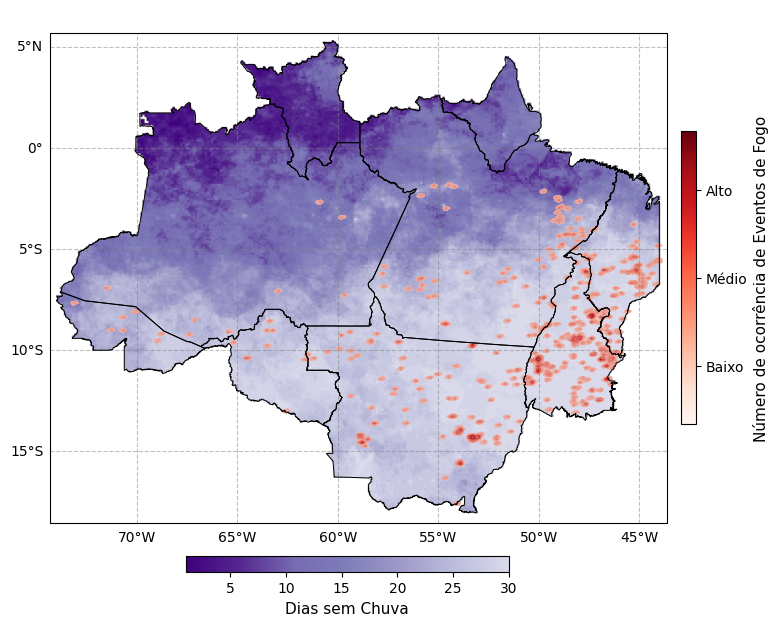


📌 Processando período: Agosto 2026


c:\Users\fabio.passos\AppData\Local\anaconda3\Lib\site-packages\cartopy\crs.py:423: RuntimeWarning: invalid value encountered in remainder
  x[to_180] = (((x[to_180] + 180) % 360) - 180)


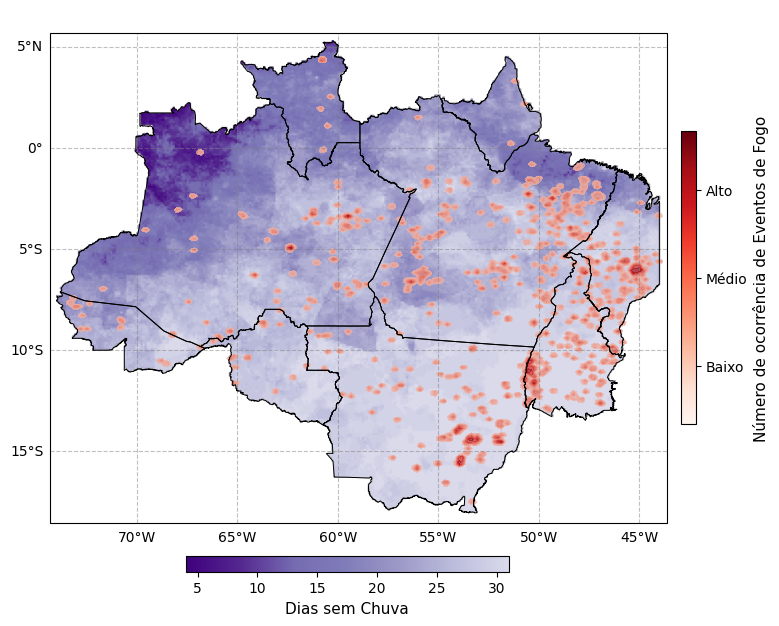

In [69]:
#| label: mapa-integrado

###############################################
## Geração de Mapas de Calor e Dias sem chuvas
###############################################

for periodo, (inicio, fim) in periodos.items():

    print(f"\n📌 Processando período: {periodo}")

    # Raster correspondente
    input_raster = outputs_tif[periodo]

    # Queimadas do período
    centroides_eventos = consulta_queimadas(inicio, fim, conn_str)



    with rasterio.open(input_raster) as src:
    # Garantir CRS compatível
        gdf_mask = amazonia_b.to_crs(src.crs)

    # Realiza o recorte 
        out_image, out_transform = mask(src, gdf_mask.geometry, crop=True) 
        out_meta = src.meta.copy() 
    
    # Tratar NoData 
        out_image = out_image.astype('float32') 
        out_image[out_image == src.nodata] = np.nan 
    
############################################################################################################################################## 
################################## Inserção da legenda de 'Dias Sem Chuva' e organização das legendas ######################################## 
############################################################################################################################################### 
    # Atualizar metadados do raster 
        out_meta.update({ "driver": "GTiff", "count": 1, "dtype": "float32", "crs": src.crs, "transform": out_transform }) 
    
    # Coordenadas dos eventos 
        lats = centroides_eventos.geometry.y 
        lons = centroides_eventos.geometry.x 
    
    # Criar figura e eixos com projeção Cartopy 
        fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': ccrs.PlateCarree()}) 
    
    ################################### Formatação dos Dias sem Chuvas ####################################################### 
    # Definir uma escala de cores personalizado (color map) para o mapa de precipitação (raster) 
    # # cmap_raster = plt.get_cmap("Purples_r", 6) 
    # # legenda discreta # cmap_raster = plt.get_cmap("Purples_r") 
    # # legenda continua 
        from matplotlib.colors import LinearSegmentedColormap 
        colors_roxo = ['#3f007d',
                    '#54278f',
                    '#756bb1',
                    '#807dba',
                    '#9e9ac8',
                    '#bcbddc',
                    '#dadaeb'
                    ]
    # colors_roxo = '#3f007d', '#54278f', '#756bb1', '#807dba', '#9e9ac8', '#bcbddc' 
    # # colors_roxo = ["#4B0082", "#6A0DAD", "#9B30FF", "#CBA0E3", "#E8D9F1"] 
    # # Roxo escuro para claro 
        cmap_raster = LinearSegmentedColormap.from_list("gradiente_roxo", colors_roxo) 
    
    # ################################### Formatação do mapa de Calor (HeatMap) ################################################## 
    # # Criar o heatmap com Seaborn (ajustando a largura de banda) 
    # # heatmap = sns.kdeplot(x=lons, y=lats, cmap="Reds", fill=True, alpha=0.7, levels=15, ax=ax, bw =0.006) 
        vermelho_5_tons = [ "#f0b4a7ff", # Coral Escuro (Mais claro da escala) 
                            "#db6055", # Vermelho Alerta 
                            '#cb181d', # Vermelho Médio 
                            '#a50f15', # Carmim 
                            '#67000d' # Vinho (Escuro) 
                            ] 
        heatmap = sns.kdeplot(x=lons, y=lats, cmap=LinearSegmentedColormap.from_list("Reds", vermelho_5_tons), fill=True, alpha=0.7, 
                            levels=15, ax=ax, bw_adjust=0.04, zorder=2,
                            transform=ccrs.PlateCarree()) # Garante a conversão correta de coordenadas no Cartopy) 
                          
    ################################## Formatação do Layout do Mapa #######################################################


    ### Alteração da cor de fundo do mapa ###
    # Cria uma cópia para não alterar o dado original e transforma 0 em NaN
        data_to_plot = out_image[0].copy()
        data_to_plot[data_to_plot == 0] = np.nan  # Substitua 0 pelo valor de fundo do seu raster

    #Para deixar o fundo roxo, substituir e inativar o comando 'data_to_plot' por 'out_image[0]' 
    # Adicionar o raster ao mapa corretamente
        img = ax.imshow(data_to_plot, cmap=cmap_raster, extent=[out_meta['transform'][2], 
                                                        out_meta['transform'][2] + out_meta['transform'][0] * out_image.shape[2], 
                                                        out_meta['transform'][5] + out_meta['transform'][4] * out_image.shape[1], 
                                                        out_meta['transform'][5]], origin="upper", transform=ccrs.PlateCarree())

    # Adicionar grade de coordenadas
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5)
        gl.right_labels = False  
        gl.top_labels = False    

    # Definir limites do mapa
        ax.set_extent([-74.3, -43.6, -18.3, 5.7])  
 

    # Adicionar polígono da Amazônia sem preenchimento
        gdf = amazonia_b
        gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.7, zorder=10) # Argumento 'zorder': define a sobreposição da camada. Qto maior o valor, mais a frente estará.


    ########################################################## Legendas ###########################################################
    ################################### Formatação da legenda dos Dias sem Chuva ##################################################
    # Adicionar barra de cores para a legenda dos 'Dias sem Chuvas'
        cbar_raster = plt.colorbar(img, ax=ax, orientation="horizontal", fraction=0.03, pad=0.06) #'pad': ajusta a distância do mapa com a legenda
        cbar_raster.set_label("Dias sem Chuva", fontsize=11)

    # Ajustando os rótulos personalizados para os 'dias sem chuvas'
    # cbar_raster.set_ticks([0, 10, 20, 30])  # Posições normalizadas na barra de cores

    ################################### Formatação da legenda do mapa de Calor (HeatMap) ###########################################
    # Adicionar barra de cores separada para o heatmap
        sm = plt.cm.ScalarMappable(cmap="Reds")
        sm.set_array([])  

        cbar_heatmap = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.021, pad=0.02) #'pad': ajusta a distância do mapa com a legenda
        cbar_heatmap.set_label("Número de ocorrência de Eventos de Fogo", fontsize=11)

    # Ajustando os rótulos personalizados para o heatmap
        cbar_heatmap.set_ticks([0.2, 0.5, 0.8])  # Posições normalizadas da barra de cores
        cbar_heatmap.set_ticklabels(["Baixo", "Médio", "Alto"])  # Rótulos personalizados> 20%, 50% e 80% de altura da legenda
    ##################################################################################################################################


    ################################### Plotar a imagem do Mapa ###########################################
    # Adicionar título
        plt.title(" ", fontsize=14)

    # Mostrar o mapa
        plt.show()